# TBMI Assignment 6
_Rijcklof Hofman s4792432_


___Ex3.2___

These exercises will now guide you through writing your own integrator for the
Hodgkin-Huxley equations.
We begin with their original formulation. Use the following:
- Integration step time of dT = 0.01
- Initialize with t = 1, I(t) = 0, and V(t) = 0
- Pulse width of 15 out of 100 integration steps, starting at t = 2

$V_{Na} = 115$

$V_{K} = −12$

$V_{L} = 10.6$

$g_{Na} = 120$

$g_{K} = 36$

$g_{L} = 0.3$

- Initialize the rate constants, using the formulas from (3.9), and then initialize the gating variables using three formulas as

$q(1) = a_{q}(1)/(a_{q}(1) + B_{q}(1))$

where $q = n,m$ or $h$

- Initialize the conductances

$g_{Na}(t) = g_{Na} m(t)^3 h(t)$

and

$g_{K}(t) = g_{K} n(t)^4$

- You will need to make a loop that uses an integrator. Let’s start with Euler integration. We wish to evaluate $dy(t)/dt = f (t,y(t))$, using the first two terms of the Taylor series expansion of the function about a point t :

$y(t+1) = y(t) + \frac{dy(t)}{dt}((t+1) - (t))$

- We are not under voltage clamp, so the total membrane current is

$I_{m} = C_{m} \frac{dV}{dt} + I_{i}$

and if $I_{m} = 0$, then $C_m \frac{\partial V}{\partial t} = -\sum_{i} i_{i}$. The $\sum_{i} i_{i} includes your ionic currents, but also the added ionic current you impose from your current pulse.Write

$dV = dT * (1/C_{M})*(-I_{pulse} - \sum_{i} I_{i} )$

and 

$V(t) = V(t-1) + dV$

- Now update the rate constants and integrate the gating variables as

$dq = dT(\alpha_{q} (1-q(t-1)) - \beta_{q} q(t-1))$

$q(t) = q(t-1) + dq$

where $q = m,n,$ or $h$.

- If you want to plot with the modern convention, use V = −(V +60).
- Plot your results for current pulses of from −500 to +500. Where is the threshold?
- If you have done this correctly, your results should look similar to figure 3.44:

___Ex 3.3___

Now that you have written an integrator, plot the relationships between the time
constants and infinite time rate constants as in figure 3.35.

## initialization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm, block_diag
import ipywidgets as widgets
from tqdm import tqdm
import os
base_path = os.paht.join("..")
os.chdir(base_path)
#os.chdir(os.path.join('C:\\Users','KHofman','Documents','Studie','KalmanPP2')) #On laptop


In [7]:
os.chdir("code")
import ukf_voss
os.chdir(os.path.join("..","notebooks"))
import Assignment6
os.chdir("..")

C:\Users\KHofman\Documents\Studie\KalmanPP2
Using jax sqrtm for jax_sqrtm with backend  [CpuDevice(id=0)]


In [8]:
u0 = np.array([
    [-0.1637, -0.2244, -0.1982, -0.1410, -0.1029, -0.0811, -0.0656, -0.0396],
    [-0.2593, -0.3580, -0.3021, -0.2008, -0.1321, -0.1028, -0.0840, -0.0516],
    [-0.2444, -0.3386, -0.2746, -0.1726, -0.0950, -0.0742, -0.0637, -0.0417],
    [-0.0055, -0.0383, 0.0012, -0.0657, -0.0395, -0.0388, -0.0387, -0.0270],
    [0.2361, 0.3685, 0.2616, 0.2237, 0.0279, -0.0174, -0.0239, -0.0183],
    [0.4698, 0.7002, 0.5627, 0.2726, 0.0939, -0.0071, -0.0171, -0.0135],
    [0.3618, 0.5613, 0.4323, 0.2754, 0.0673, -0.0056, -0.0130, -0.0104],
    [0.2442, 0.2669, 0.2571, 0.1067, 0.0152, -0.0049, -0.0077, -0.0061]
])

a0 = np.array([
    [0.4104, 0.5339, 0.4345, 0.2786, 0.1904, 0.1454, 0.1157, 0.0694],
    [0.7058, 0.9183, 0.6974, 0.4049, 0.2427, 0.1821, 0.1465, 0.0893],
    [0.9263, 1.1846, 0.8515, 0.4104, 0.1757, 0.1283, 0.1085, 0.0707],
    [1.0750, 1.4204, 1.0146, 0.4695, 0.0921, 0.0646, 0.0636, 0.0444],
    [1.0367, 1.4612, 0.9507, 0.4993, 0.0532, 0.0309, 0.0380, 0.0293],
    [0.7878, 1.1079, 0.7914, 0.3707, 0.0468, 0.0205, 0.0267, 0.0213],
    [0.4156, 0.5573, 0.4218, 0.1886, 0.0255, 0.0150, 0.0202, 0.0162],
    [0.1386, 0.1823, 0.1406, 0.0437, 0.0083, 0.0090, 0.0119, 0.0095]
])

i0 = np.concatenate((u0.ravel(), a0.ravel()))

## running the filter

In [9]:
noise_factor = 1.
obs_noise = 0.2 * np.sqrt(noise_factor)
nature0 = Assignment6.WilsonCowanNature(ll=800, dT=0.01, dt=0.001, initial_condition=i0, run_until=799, obs_noise=obs_noise)

In [10]:
noise_factor = 1
obs_noise = 0.2 * np.sqrt(noise_factor)

f = 8
g = 8
q = 0.015
variance_inflate = 1.3
# Q_par = np.diag([q, q])
Q_par0 = np.array([])
#Q_var0 = np.diag((nature.R * variance_inflate, ) * 2 * f * g)
Q_var0 = (variance_inflate
		  * np.cov(nature0.x0))
wilson_cowan_model = Assignment6.WilsonCowanModelWithParameterTracking(Q_par=Q_par0, Q_var=Q_var0, R=nature0.R)
uk_filter = ukf_voss.UKFVoss(model=wilson_cowan_model, ll=800, dT=0.01, dt=0.001, variance_inflation=1.02)
x_hat_orig, Pxx_orig, Ks_orig, errors_orig = uk_filter.filter(nature0.y, initial_condition=i0, run_until=799)

100%|██████████| 799/799 [02:36<00:00,  5.11it/s]


In [11]:
@widgets.interact(i=(0, 799 - 1))
def img_render(i=0):
	# fig, ax = plt.subplots(1, 3, figsize=(12, 8))
	plt.subplot(1, 3, 1)
	plt.imshow(nature0.x0[:64, i].reshape((8, 8)))
	plt.clim(0, nature0.x0[:64, :].max())

	plt.subplot(1, 3, 2)
	plt.imshow(x_hat_orig[:64, i].reshape((8, 8)))
	plt.clim(0, nature0.x0[:64, :].max())
	plt.subplot(1, 3, 3)
	plt.imshow(nature0.y[:64, i].reshape((8, 8)))
	plt.clim(0, nature0.x0[:64, :].max())

interactive(children=(IntSlider(value=0, description='i', max=798), Output()), _dom_classes=('widget-interact'…

## control without Kalman

In [12]:
# control without Kalman
noise_factor = 1
obs_noise = 0.2 * np.sqrt(noise_factor)
gain = -0.044
nature_ctrl_nok = Assignment6.WilsonCowanNature(ll=800, dT=0.01, dt=0.001, initial_condition=i0, run_until=100, obs_noise=obs_noise)
nature_no_ctrl = Assignment6.WilsonCowanNature(ll=1600, dT=0.01, dt=0.001, initial_condition=i0, run_until=800, obs_noise=obs_noise)

for n in range(100,799):
	nature_ctrl_nok.integrate_solveivp(run_until=n)
	nature_ctrl_nok.observations(n, n+1)
	nature_ctrl_nok.set_control(gain*nature_ctrl_nok.y[:,n])


In [13]:
nature = nature_ctrl_nok

@widgets.interact(i=(0, 799-1))
def img_render(i=0):
	plt.subplot(1, 2, 1)
	plt.imshow(nature.x0[:64,i].reshape((8,8)))
	plt.clim(0, nature.x0[:64,:].max())
	plt.subplot(1, 2, 2)
	plt.imshow(nature_ctrl_nok.x0[:64,i].reshape((8,8)))
	plt.clim(0, nature_ctrl_nok.x0[:64,:].max())

interactive(children=(IntSlider(value=0, description='i', max=798), Output()), _dom_classes=('widget-interact'…

## Control with Kalman

In [14]:
# control with Kalman
noise_factor = 1
obs_noise = 0.2 * np.sqrt(noise_factor)
# gain = 0.0003
gain = -0.015
variance_inflate = 2.
baseline_run = 800
total_duration = 7000
nature_no_ctrl = Assignment6.WilsonCowanNature(ll=total_duration, dT=0.01, dt=0.001, initial_condition=i0, obs_noise=obs_noise, run_until=total_duration-1)

nature_ctrl_k = Assignment6.WilsonCowanNature(ll=total_duration, dT=0.01, dt=0.001, initial_condition=i0, run_until=baseline_run, obs_noise=obs_noise)

Q_par = np.array([])
#Q_var0 = np.diag((nature.R * variance_inflate, ) * 2 * f * g)
Q_var = variance_inflate * np.cov(nature_ctrl_k.x0[:, :baseline_run])

wilson_cowan_model = Assignment6.WilsonCowanModelWithParameterTracking(Q_par=Q_par, Q_var=Q_var, R=nature_ctrl_k.R)
uk_filter = ukf_voss.UKFVoss(model=wilson_cowan_model, ll=total_duration, dT=0.01, dt=0.001, variance_inflation=40.)
x_hat0, Pxx0, Ks0, errors0 = uk_filter.filter(nature_ctrl_k.y, initial_condition=i0, run_until=baseline_run,
 												disable_progress=False)

100%|██████████| 800/800 [02:40<00:00,  4.99it/s]


In [15]:
for n in tqdm(range(baseline_run+1, total_duration-2)):
	nature_ctrl_k.integrate_solveivp(run_until=n)
	# control = gain*nature.y[:,n]
	control = gain * x_hat0[:64, n-1]
	nature_ctrl_k.set_control(control)
	wilson_cowan_model.set_control(control)
	x_hat0, Pxx0, Ks0, errors0 = uk_filter.filter(nature_ctrl_k.y, initial_condition=None, run_until=n,
												  disable_progress=True)

100%|██████████| 6197/6197 [20:22<00:00,  5.07it/s]


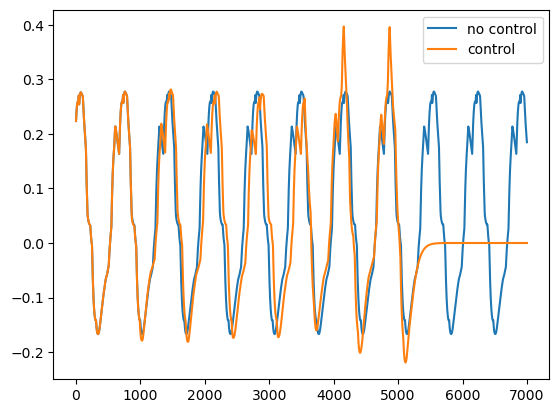

In [16]:
plt.plot(nature_no_ctrl.x0[35, :], label='no control')
plt.plot(nature_ctrl_k.x0[35, :], label='control')
plt.legend()

In [17]:
@widgets.interact(i=(0, total_duration - 2))
def img_render(i=0):
	# fig, ax = plt.subplots(1, 3, figsize=(12, 8))
	plt.subplot(1, 4, 1)
	plt.imshow(nature_ctrl_k.x0[:64, i].reshape((8, 8)))
	plt.clim(0, nature_no_ctrl.x0[:64, :].max())

	plt.subplot(1, 4, 2)
	plt.imshow(x_hat0[:64, i].reshape((8, 8)))
	plt.clim(0, nature_no_ctrl.x0[:64, i].max())
	plt.subplot(1, 4, 3)
	plt.imshow(nature_ctrl_k.y[:64, i].reshape((8, 8)))
	plt.clim(0, nature_no_ctrl.x0[:64, :].max())

	plt.subplot(1, 4, 4)
	plt.imshow(nature_no_ctrl.x0[:64, i].reshape((8, 8)))
	plt.clim(0, nature_no_ctrl.x0[:64, :].max())


interactive(children=(IntSlider(value=0, description='i', max=6998), Output()), _dom_classes=('widget-interact…

In [18]:
Pxx_tr = np.trace(Pxx0, axis1=0, axis2=1)

C:\Users\KHofman\AppData\Local\Temp\ipykernel_32040\1265832794.py:1: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(Pxx_tr))


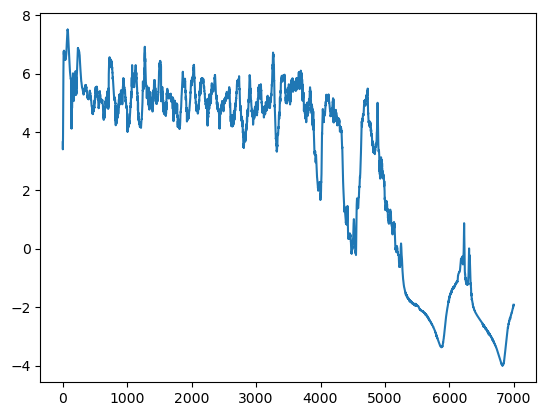

In [19]:
plt.plot(np.log(Pxx_tr))